<a href="https://colab.research.google.com/github/LinaMariaCastro/curso-ia-para-economia/blob/main/clases/4_Aprendizaje_no_supervisado/3_Taller_PCA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>



# **Inteligencia Artificial con Aplicaciones en Economía I**

- 👩‍🏫 **Profesora:** [Lina María Castro](https://www.linkedin.com/in/lina-maria-castro)  
- 📧 **Email:** [lmcastroco@gmail.com](mailto:lmcastroco@gmail.com)  
- 🎓 **Universidad:** Universidad Externado de Colombia - Facultad de Economía

# **Taller: Creación de un Índice de Clima de Inversión con Análisis de Componentes Principales (PCA)**

**IMPORTANTE**: Guarda una copia de este notebook en tu Google Drive o computador.

**Taller en grupos de 3**

**Nombres estudiantes:**

-Andrés Santiago Cristiano Trujillo
-Katherin Alejandra Pérez Martínez

**Forma de entrega:**

- Nombrar el archivo de la siguiente forma:“Taller_PCA_apellidos.ipynb”.
- Suba el Jupyter Notebook a su cuenta en Github y envíe el link en el siguiente Forms: https://forms.cloud.microsoft/r/q1ZSe3N80C.

**IMPORTANTE:** No se recibirán talleres en Google Colab, el notebook debe estar subido en Github.

**Plazo de entrega:**

28 de abril de 2026, máximo a las 11:59 p.m. Tenga en cuenta que luego de esa hora el formulario en forms se cierra. El Jupupyter Notebook también debe quedar subido en Github antes de esa hora.

**Instrucciones Generales:**

Completa el código en las celdas marcadas con `### TU CÓDIGO AQUÍ ###`. Puedes añadir más celdas si lo requieres.

### Contexto

**Escenario:** Eres un científico de datos recién contratado como consultor experto por el **Ministerio de Comercio, Industria y Turismo (MinCIT)** de Colombia. Tu tarea principal es crear un **'Índice de Clima para la Inversión'** cuantitativo que permita clasificar y comparar el entorno competitivo de los países de América Latina y el Caribe. Este índice orientará las estrategias de integración regional y las políticas para atraer Inversión Extranjera Directa (IED).

**Objetivo:** Utilizando la base de datos de indicadores provista (preparada para este análisis) y la técnica de **Análisis de Componentes Principales (PCA)**, deberás extraer la "variable latente" que resume el clima de inversión, interpretar sus pesos económicos y presentar un ranking de países con recomendaciones ejecutivas.


## Ejercicio 1: Configuración Inicial, Carga y Exploración de Datos

1.1 Importa las librerías necesarias

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [2]:
# Configuraciones de visualización
pd.options.display.max_columns = None
pd.options.display.float_format = '{:,.2f}'.format
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

1.2 Carga el dataset "Indicators.csv" que se encuentra en el repositorio del curso, carpeta "datasets". El dataframe debe llamarse "df_indicators".

In [3]:
df_indicators = pd.read_csv('/content/drive/MyDrive/IA Economia/Indicators.csv')

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [5]:
# Debe ser (121, 4)
print("Dimensiones del DataFrame Indicators:")
print(df_indicators.shape)

Dimensiones del DataFrame Indicators:
(121, 4)


In [6]:
print("\nInformación general del DataFrame:")
df_indicators.info()


Información general del DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 121 entries, 0 to 120
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   CountryCode    121 non-null    object 
 1   IndicatorCode  121 non-null    object 
 2   Year           121 non-null    int64  
 3   Value          121 non-null    float64
dtypes: float64(1), int64(1), object(2)
memory usage: 3.9+ KB


1.3 Carga el dataset "Country.csv" que se encuentra en el repositorio del curso, carpeta "datasets". El dataframe debe llamarse "df_countries".

In [7]:
df_countries = pd.read_csv("/content/drive/MyDrive/IA Economia/Country.csv")

In [8]:
# Debe ser (14, 3)
print("Dimensiones del DataFrame Countries:")
print(df_countries.shape)

Dimensiones del DataFrame Countries:
(14, 3)


In [9]:
print("\nInformación general del DataFrame:")
df_countries.info()


Información general del DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14 entries, 0 to 13
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   CountryCode  14 non-null     object
 1   ShortName    14 non-null     object
 2   Region       14 non-null     object
dtypes: object(3)
memory usage: 468.0+ bytes


### Ejercicio 2: Selección y Preparación de Datos

Para el análisis del MinCIT, hemos preseleccionado un conjunto de variables clave.

2.1. Utiliza el diccionario para modificar los códigos de los indicadores por sus descripciones

In [27]:
nombre_indicadores = {
    'NV.AGR.TOTL.ZS': 'Agricultura (% del PIB)',
    'NE.TRD.GNFS.ZS': 'Comercio (% del PIB)',
    'NY.GDP.MKTP.KD.ZG': 'Crecimiento del PIB (%)',
    'FP.CPI.TOTL.ZG': 'Inflación (%)',
    'GC.DOD.TOTL.GD.ZS': 'Deuda del gob. central (% del PIB)',
    'SE.XPD.TOTL.GD.ZS': 'Gasto en educación (% del PIB)',
    'SH.XPD.CHEX.GD.ZS': 'Gasto en salud (% del PIB)',
    'IQ.CPA.BREG.XQ': 'Facilidad para hacer negocios',
    'IC.LGL.DURS': 'Días para cumplir contratos',
    'TX.VAL.MRCH.XD.WD': 'Exportaciones (US$)',
    'TM.VAL.MRCH.XD.WD': 'Importaciones (US$)'
}

In [11]:
df_indicators['IndicatorCode'] = df_indicators['IndicatorCode'].replace(nombre_indicadores)
print(df_indicators['IndicatorCode'].unique())

['Agricultura (% del PIB)' 'Comercio (% del PIB)'
 'Crecimiento del PIB (%)' 'Inflación (%)'
 'Deuda del gob. central (% del PIB)' 'Gasto en educación (% del PIB)'
 'Gasto en salud (% del PIB)' 'Facilidad para hacer negocios'
 'Días para cumplir contratos' 'Exportaciones (US$)' 'Importaciones (US$)']


2.2. Utiliza pivot table para crear un nuevo dataframe donde se encuentren los países como filas y los indicadores como columnas. Llama a este dataframe "df_pivot". No olvides colocar .reset_index() para que la columna de código de países quede como una columna y no como el índice.

In [12]:
df_pivot = df_indicators.pivot_table(index='CountryCode',columns='IndicatorCode',  values='Value').reset_index()

df_pivot.head()


IndicatorCode,CountryCode,Agricultura (% del PIB),Comercio (% del PIB),Crecimiento del PIB (%),Deuda del gob. central (% del PIB),Días para cumplir contratos,Exportaciones (US$),Facilidad para hacer negocios,Gasto en educación (% del PIB),Gasto en salud (% del PIB),Importaciones (US$),Inflación (%)
0,ARG,11.73,32.43,-0.45,73.07,873.48,"20,153,725,105.95",2.19,2.38,4.09,"18,058,208,718.45",44.28
1,BOL,NaN,54.39,1.76,66.69,798.96,"39,036,984,373.93",NaN,5.37,5.05,"36,977,180,000.81",36.05
2,BRA,12.79,60.18,2.59,57.20,741.68,"56,043,860,610.92",3.57,4.56,5.31,"50,026,448,161.33",25.60
3,CHL,6.75,74.31,7.65,42.83,535.92,"90,542,560,043.59",5.88,6.38,8.29,"80,536,582,307.19",12.62
4,COL,6.92,59.96,6.60,47.95,633.90,NaN,NaN,6.34,6.30,"67,424,196,254.97",11.61


2.3. Crea el dataframe "df_final", realizando un merge entre "df_pivot" y "df_countries" con el fin de agregar el nombre de los países.

In [13]:
df_final = pd.merge( df_pivot, df_countries[['CountryCode', 'ShortName']], on='CountryCode',how='left')

cols = ['ShortName'] + [c for c in df_final.columns if c != 'ShortName']
df_final = df_final[cols]

df_final = df_final.rename(columns={'ShortName': 'CountryName'})

df_final.head()

,CountryName,CountryCode,Agricultura (% del PIB),Comercio (% del PIB),Crecimiento del PIB (%),Deuda del gob. central (% del PIB),Días para cumplir contratos,Exportaciones (US$),Facilidad para hacer negocios,Gasto en educación (% del PIB),Gasto en salud (% del PIB),Importaciones (US$),Inflación (%)
0,Argentina,ARG,11.73,32.43,-0.45,73.07,873.48,"20,153,725,105.95",2.19,2.38,4.09,"18,058,208,718.45",44.28
1,Bolivia,BOL,NaN,54.39,1.76,66.69,798.96,"39,036,984,373.93",NaN,5.37,5.05,"36,977,180,000.81",36.05
2,Brasil,BRA,12.79,60.18,2.59,57.20,741.68,"56,043,860,610.92",3.57,4.56,5.31,"50,026,448,161.33",25.60
3,Chile,CHL,6.75,74.31,7.65,42.83,535.92,"90,542,560,043.59",5.88,6.38,8.29,"80,536,582,307.19",12.62
4,Colombia,COL,6.92,59.96,6.60,47.95,633.90,NaN,NaN,6.34,6.30,"67,424,196,254.97",11.61


2.4. Elimina las columnas "Region" y "CountryCode" y establece la columna 'ShortName' como el índice del dataframe

In [14]:
df_final = df_final.drop(columns=['Region', 'CountryCode'], errors='ignore')
df_final = df_final.set_index('CountryName')
df_final.head()

,Agricultura (% del PIB),Comercio (% del PIB),Crecimiento del PIB (%),Deuda del gob. central (% del PIB),Días para cumplir contratos,Exportaciones (US$),Facilidad para hacer negocios,Gasto en educación (% del PIB),Gasto en salud (% del PIB),Importaciones (US$),Inflación (%)
CountryName,,,,,,,,,,,
Argentina,11.73,32.43,-0.45,73.07,873.48,"20,153,725,105.95",2.19,2.38,4.09,"18,058,208,718.45",44.28
Bolivia,NaN,54.39,1.76,66.69,798.96,"39,036,984,373.93",NaN,5.37,5.05,"36,977,180,000.81",36.05
Brasil,12.79,60.18,2.59,57.20,741.68,"56,043,860,610.92",3.57,4.56,5.31,"50,026,448,161.33",25.60
Chile,6.75,74.31,7.65,42.83,535.92,"90,542,560,043.59",5.88,6.38,8.29,"80,536,582,307.19",12.62
Colombia,6.92,59.96,6.60,47.95,633.90,NaN,NaN,6.34,6.30,"67,424,196,254.97",11.61


### Ejercicio 3: Limpieza de Datos (Imputación de Valores Faltantes)

En la vida real de un economista, los datos tienen huecos. El PCA requiere bases completas. Usaremos una estrategia de imputación por la media para resolver los NaN.

3.1. Revisa cuántos valores faltantes hay en cada columna

In [15]:
missing_values = df_final.isnull().sum()
print("Valores faltantes por columna:")
print(missing_values)


Valores faltantes por columna:
Agricultura (% del PIB)               4
Comercio (% del PIB)                  3
Crecimiento del PIB (%)               0
Deuda del gob. central (% del PIB)    4
Días para cumplir contratos           2
Exportaciones (US$)                   3
Facilidad para hacer negocios         5
Gasto en educación (% del PIB)        3
Gasto en salud (% del PIB)            4
Importaciones (US$)                   3
Inflación (%)                         2
dtype: int64


3.2. Para cada columna, utiliza el promedio del resto de países de Latinoamérica para imputar los valores faltantes. El resultado debe quedar en un dataframe llamado "df_final_imputed". Al final revisa que no haya quedado ningún valor faltante en las columnas del dataframe.

In [16]:
df_final_imputed = df_final.copy()
for columna in df_final_imputed.columns:
    media_columna = df_final_imputed[columna].mean()
    df_final_imputed[columna] = df_final_imputed[columna].fillna(media_columna)

total_faltantes = df_final_imputed.isnull().sum().sum()

print(f"Total de valores faltantes después de la imputación: {total_faltantes}")

df_final_imputed.head()

Total de valores faltantes después de la imputación: 0


,Agricultura (% del PIB),Comercio (% del PIB),Crecimiento del PIB (%),Deuda del gob. central (% del PIB),Días para cumplir contratos,Exportaciones (US$),Facilidad para hacer negocios,Gasto en educación (% del PIB),Gasto en salud (% del PIB),Importaciones (US$),Inflación (%)
CountryName,,,,,,,,,,,
Argentina,11.73,32.43,-0.45,73.07,873.48,"20,153,725,105.95",2.19,2.38,4.09,"18,058,208,718.45",44.28
Bolivia,8.86,54.39,1.76,66.69,798.96,"39,036,984,373.93",3.96,5.37,5.05,"36,977,180,000.81",36.05
Brasil,12.79,60.18,2.59,57.20,741.68,"56,043,860,610.92",3.57,4.56,5.31,"50,026,448,161.33",25.60
Chile,6.75,74.31,7.65,42.83,535.92,"90,542,560,043.59",5.88,6.38,8.29,"80,536,582,307.19",12.62
Colombia,6.92,59.96,6.60,47.95,633.90,"56,527,087,039.04",3.96,6.34,6.30,"67,424,196,254.97",11.61


### Ejercicio 4: Matriz de Correlaciones y Estandarización de Variables

4.1. Grafica un mapa de calor para ver las correlaciones entre las variables.

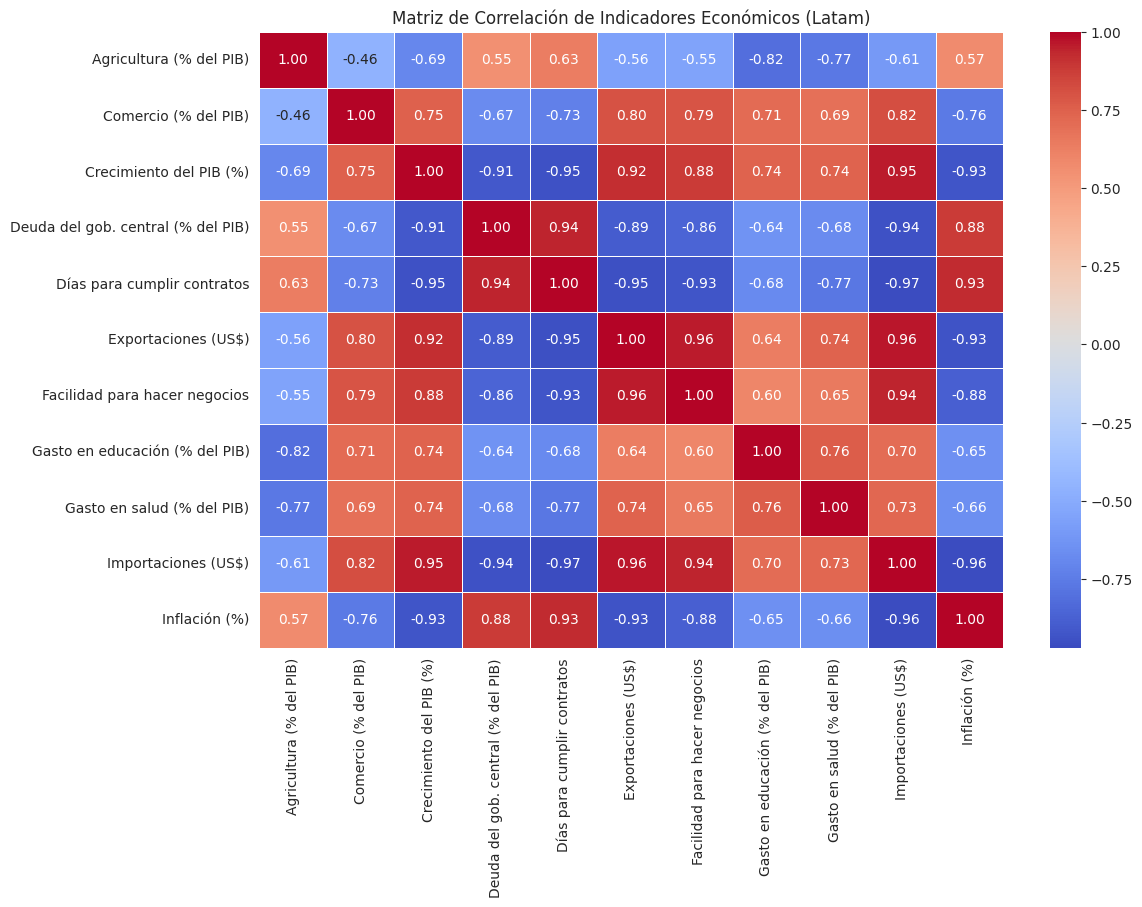

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt

corr_matrix = df_final_imputed.corr()

plt.figure(figsize=(12, 8))

sns.heatmap(corr_matrix,annot=True,cmap='coolwarm',fmt=".2f", linewidths=0.5)

plt.title('Matriz de Correlación de Indicadores Económicos (Latam)')
plt.show()

4.2. Interpreta los resultados resaltando las correlaciones más relevantes.

La matriz muestra que el crecimiento del PIB es la variable clave, ya que está fuertemente relacionado de forma positiva con exportaciones e importaciones, lo que indica que las economías que más crecen son también las más abiertas al comercio. A su vez, el crecimiento tiene relaciones negativas muy altas con la inflación y la deuda, lo que sugiere que la estabilidad macroeconómica es fundamental para un buen desempeño económico.

También se observa que el sector externo está muy interconectado (exportaciones e importaciones con correlaciones cercanas a 1), mientras que la inflación, la deuda y los días para cumplir contratos se agrupan como factores negativos, asociados a menor crecimiento y menor dinamismo económico. Esto resalta la importancia de las instituciones y del control macroeconómico.

Por último, variables como educación y salud tienen relaciones positivas moderadas con el crecimiento, mientras que la agricultura presenta correlaciones negativas con casi todos los indicadores de desarrollo, lo que sugiere que un mayor peso de este sector está asociado a economías menos desarrolladas.

4.3. Las exportaciones están en miles de millones de dólares y el crecimiento en porcentajes de un dígito. PCA busca varianzas, por lo que estandarizar (Media 0, Desviación 1) es un paso matemático obligatorio para no sesgar el modelo hacia las variables nominales grandes.  Estandariza todas las variables del dataframe y almacena el resultado en X_scaled.

In [18]:
from sklearn.preprocessing import StandardScaler

X = df_final_imputed.select_dtypes(include=[np.number])
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns, index=X.index)

print('Media de las variables estandarizadas:')
print(X_scaled.mean().round(4))
print('\nDesviación estándar:')
print(X_scaled.std().round(4))

Media de las variables estandarizadas:
Agricultura (% del PIB)              -0.00
Comercio (% del PIB)                  0.00
Crecimiento del PIB (%)               0.00
Deuda del gob. central (% del PIB)    0.00
Días para cumplir contratos           0.00
Exportaciones (US$)                   0.00
Facilidad para hacer negocios         0.00
Gasto en educación (% del PIB)       -0.00
Gasto en salud (% del PIB)            0.00
Importaciones (US$)                  -0.00
Inflación (%)                        -0.00
dtype: float64

Desviación estándar:
Agricultura (% del PIB)              1.04
Comercio (% del PIB)                 1.04
Crecimiento del PIB (%)              1.04
Deuda del gob. central (% del PIB)   1.04
Días para cumplir contratos          1.04
Exportaciones (US$)                  1.04
Facilidad para hacer negocios        1.04
Gasto en educación (% del PIB)       1.04
Gasto en salud (% del PIB)           1.04
Importaciones (US$)                  1.04
Inflación (%)                  

### Ejercicio 5: Aplicación de PCA

Vamos a correr PCA para identificar el número de componentes. Buscamos capturar la mayor cantidad de información (varianza) con la menor cantidad de dimensiones.

5.1. Corre PCA sobre X_scaled y calcula la varianza acumulada. Almacénala en la variable "varianza_acumulada".

In [19]:
from sklearn.decomposition import PCA
import numpy as np
pca = PCA()
pca.fit(X_scaled)

varianza_acumulada = np.cumsum(pca.explained_variance_ratio_)
print(varianza_acumulada)

[0.80432386 0.89486154 0.93597174 0.95991133 0.97641891 0.9864744
 0.99249496 0.99665217 0.99895635 0.99961687 1.        ]


5.2. Similar a como lo vimos en clase, grafica la varianza explicada acumulada por componente.

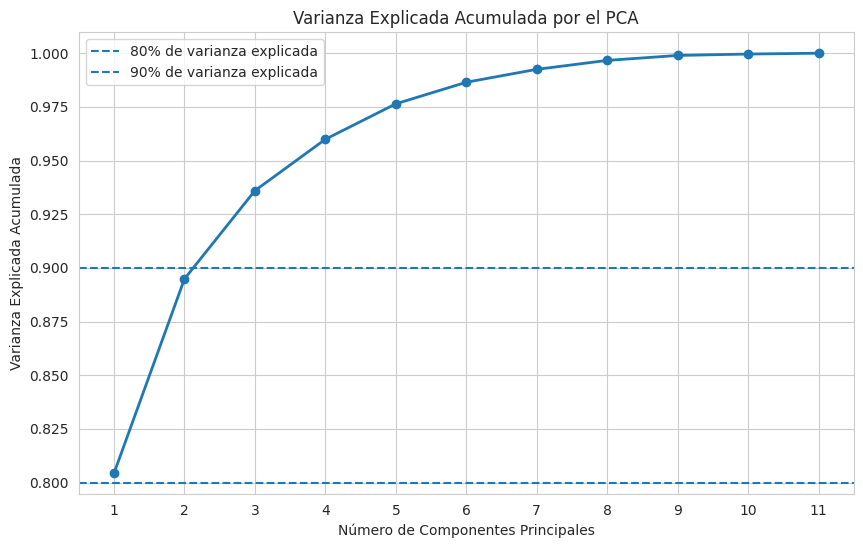

In [20]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
plt.plot(range(1, len(varianza_acumulada)+1),
         varianza_acumulada,
         marker='o',
         linewidth=2)

plt.axhline(y=0.80, linestyle='--', label='80% de varianza explicada')
plt.axhline(y=0.90, linestyle='--', label='90% de varianza explicada')

plt.xlabel('Número de Componentes Principales')
plt.ylabel('Varianza Explicada Acumulada')
plt.title('Varianza Explicada Acumulada por el PCA')
plt.xticks(range(1, len(varianza_acumulada)+1))
plt.grid(True)
plt.legend()
plt.show()

5.3. Realiza un análisis del gráfico anterior.

El gráfico muestra que el PCA logra concentrar gran parte de la información en pocos componentes. El primer componente explica cerca del 80% de la varianza, lo que indica que hay una fuerte relación entre las variables. Con dos componentes ya se alcanza aproximadamente el 90%, por lo que se puede reducir la dimensionalidad sin perder mucha información.

A partir del tercer componente, la ganancia de varianza es cada vez menor, evidenciando rendimientos decrecientes. En este caso, una elección adecuada sería trabajar con 2 o 3 componentes principales, ya que capturan la mayor parte de la variabilidad y simplifican el análisis.

### Ejercicio 6: Interpretación Económica de los Componentes (Loadings)

Nos vamos a quedar con un solo componente. Vamor a analizar qué variables originales alimentan a este componente.

6.1. Corre nuevamente el PCA, pero ahora indicando que tenga en cuenta solo 1 componente. Almacena el modelo en "pca_final" y los resultados en "X_pca".

In [21]:
pca_final = PCA(n_components=1)
X_pca = pca_final.fit_transform(X_scaled)

print("Dimensiones del nuevo conjunto:", X_pca.shape)


Dimensiones del nuevo conjunto: (14, 1)


6.2. Grafica el mapa de calor de los loadings como lo vimos en clase

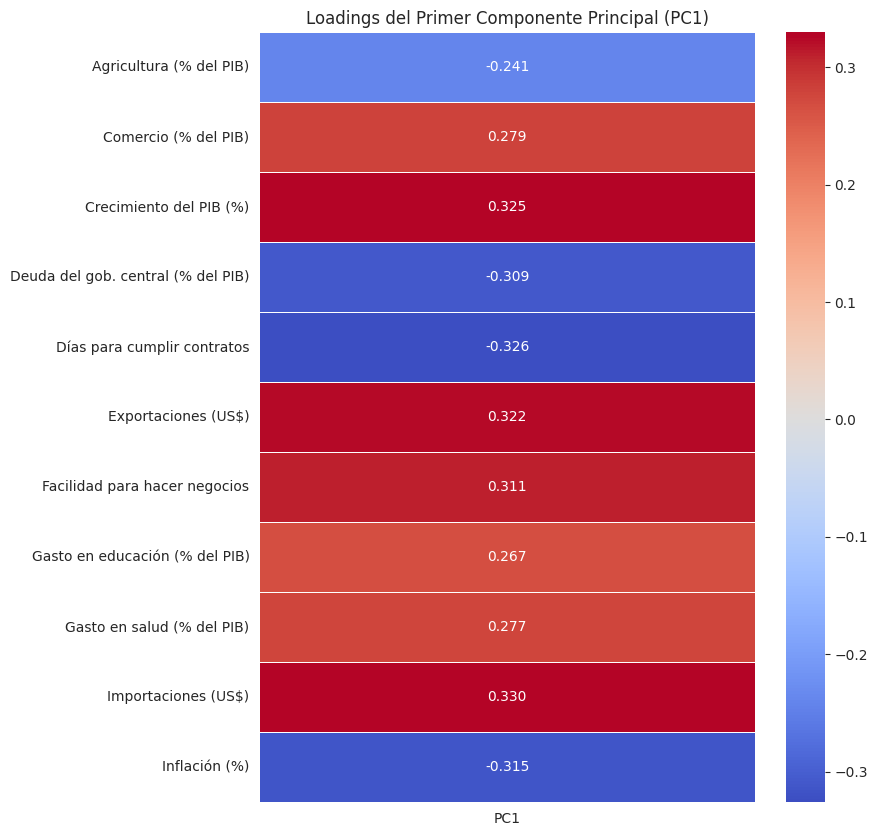

In [22]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

loadings = pd.DataFrame(
    pca_final.components_.T,
    columns=['PC1'],
    index=X_scaled.columns
)

plt.figure(figsize=(8,10))
sns.heatmap(loadings,
            annot=True,
            cmap='coolwarm',
            center=0,
            fmt='.3f',
            linewidths=0.5)

plt.title('Loadings del Primer Componente Principal (PC1)')
plt.show()


6.3. Realiza una interpretación de los loadings. ¿Cuáles variables tienen las cargas altas y positivas y cuáles las cargas altas y negativas? De acuerdo con este análisis, ¿consideras que efectivamente podemos utilizar el componente 1 como un índice del clima para la inversión en cada país de Latinoamérica? ¿por qué si o por qué no?

Las cargas altas y positivas en el PC1 son principalmente: importaciones (0.330), crecimiento del PIB (0.325), exportaciones (0.322), facilidad para hacer negocios (0.311), comercio (0.279), gasto en salud (0.277) y gasto en educación (0.267). Estas variables están asociadas a economías más dinámicas, abiertas y con mejores condiciones institucionales.

Las cargas altas y negativas son: días para cumplir contratos (-0.326), inflación (-0.315) y deuda del gobierno (-0.309), además de agricultura (-0.241) en menor medida. Estas reflejan obstáculos o debilidades económicas e institucionales.

Con esto, sí tiene sentido usar el PC1 como un índice de clima de inversión, porque combina factores que favorecen la inversión (crecimiento, apertura, facilidad de negocios) y penaliza los que la dificultan (inflación, burocracia, endeudamiento). Es decir, captura bien la “dirección” de un buen vs mal entorno económico.

Sin embargo, no es perfecto, porque simplifica mucho la realidad y puede dejar por fuera otros factores importantes (como estabilidad política o seguridad).

### Ejercicio 7: Creación del 'Índice de Clima para la Inversión'

Asignaremos el CP1 como nuestro 'Índice de Clima para la Inversión' y construiremos el ranking regional.

In [23]:
df_final_imputed['Indice_Inversion'] = X_pca[:, 0]

df_final = df_final_imputed.sort_values(by='Indice_Inversion',ascending=False)

7.1. Ordena el df_final por el índice de clima para la inversión de mayor a menor valor del índice.

In [24]:
df_final = df_final.sort_values( by='Indice_Inversion',ascending=False)


7.2. Convierte 'ShortName' en una columna del dataframe.

In [25]:
df_final = df_final.reset_index()
if 'index' in df_final.columns:
    df_final = df_final.rename(columns={'index': 'ShortName'})

7.3. Utiliza un barplot para mostrar los resultados del Índice de Clima para la Inversión. En el eje y deben ir los países y en el eje X el puntaje del índice. No olvides colocar título al gráfico y a los ejes.

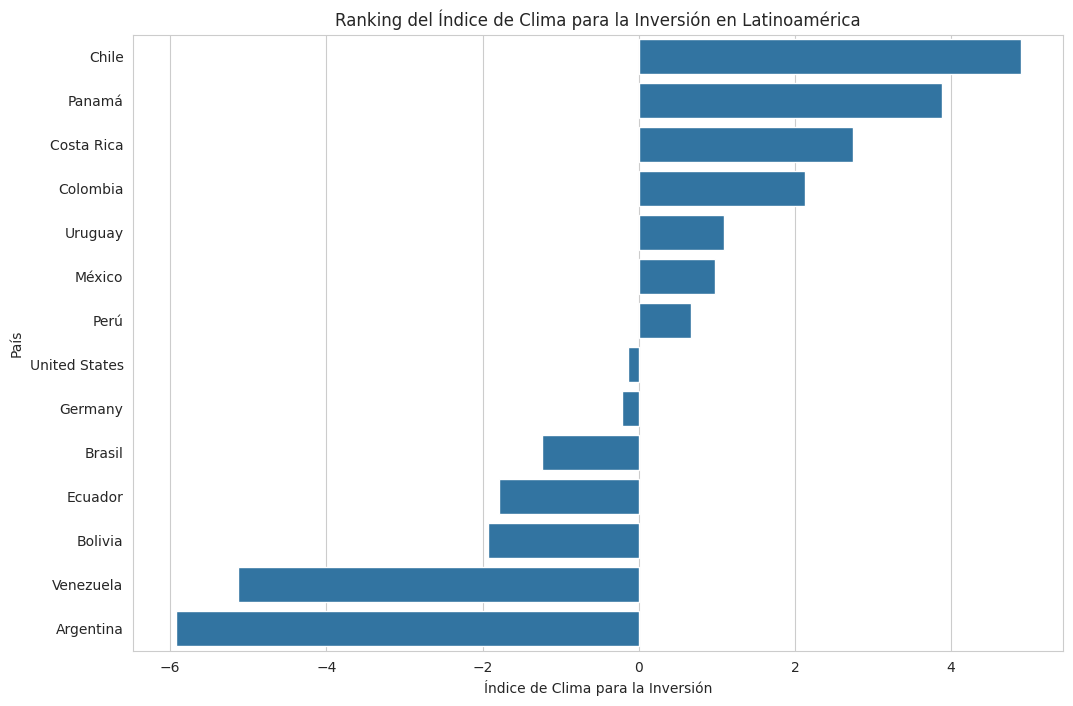

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,8))
sns.barplot(
    data=df_final,
    x='Indice_Inversion',
    y='CountryName'
)

plt.title('Ranking del Índice de Clima para la Inversión en Latinoamérica')
plt.xlabel('Índice de Clima para la Inversión')
plt.ylabel('País')
plt.show()

7.4. Analiza los resultados del gráfico y redacta una conclusiones para el MinCIT sobre el clima de inversión en la región, quiénes son nuestros competidores en la atracción de capitales extranjeros y por qué, en qué son mejores que Colombia.

El gráfico evidencia que Colombia se ubica en una posición intermedia-alta dentro de la región en términos de clima de inversión, con un índice positivo que refleja condiciones favorables, pero aún por debajo de los líderes regionales. Países como Chile, Panamá y Costa Rica presentan una ventaja clara, lo que los convierte en los principales competidores de Colombia en la atracción de capital extranjero.

Desde una perspectiva para el MinCIT, estos países no solo compiten directamente con Colombia, sino que lo hacen con atributos diferenciadores. Chile destaca por su alta estabilidad institucional, solidez macroeconómica y reglas de juego predecibles, lo que reduce la percepción de riesgo para los inversionistas. Panamá, por su parte, aprovecha su posición estratégica como hub logístico y financiero, complementado con incentivos fiscales y una fuerte integración al comercio internacional. Costa Rica sobresale por su capital humano calificado, estabilidad política y su especialización en sectores de alto valor agregado como tecnología y servicios.

En comparación, aunque Colombia ofrece un mercado atractivo por su tamaño, ubicación geográfica y potencial de crecimiento, aún enfrenta desafíos en aspectos clave como la estabilidad regulatoria, la seguridad jurídica y la eficiencia institucional. Estas brechas explican por qué, pese a tener un desempeño positivo, no lidera el ranking.

En conclusión, Colombia es un competidor relevante en la región, pero para consolidarse como destino líder de inversión extranjera debe fortalecer la confianza institucional, mejorar la consistencia en sus políticas públicas y avanzar en la reducción de incertidumbre regulatoria, cerrando así la brecha frente a los países que actualmente marcan la pauta en América Latina.